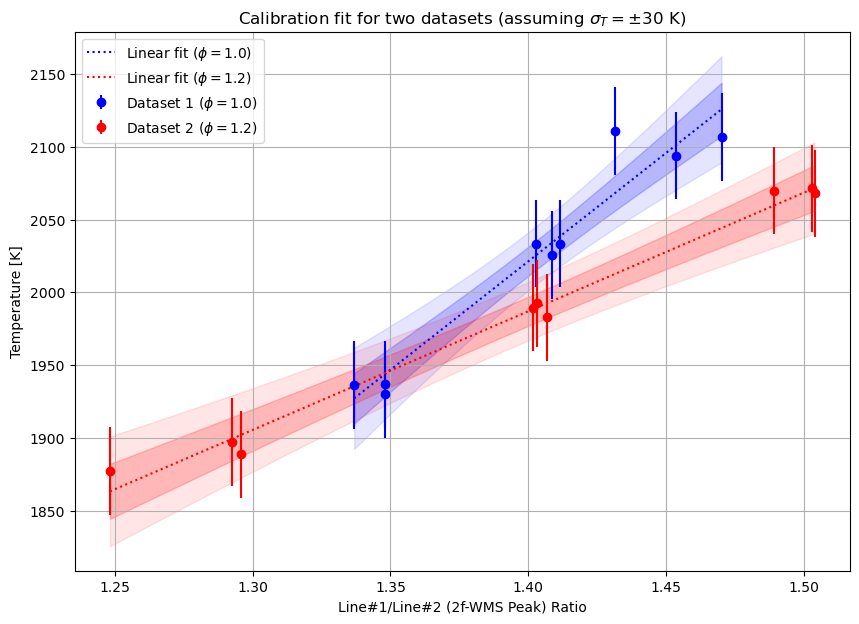

===== Výsledky dataset 1 =====
a1 = 1489.54 ± 221.09
b1 = -64.12 ± 309.95
cov(a1,b1) = -68490.09
χ² = 3.01
χ²_red = 0.43

===== Výsledky dataset 2 =====
a2 = 815.03 ± 109.80
b2 = 845.91 ± 153.37
cov(a2,b2) = -16804.32
χ² = 0.67
χ²_red = 0.10


In [4]:
# ============================================
# 1. Import knihoven
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================
# 2. Vstupní data (dataset 1 + dataset 2)
# ============================================
xP_ratio1 = np.array([1.33684,1.3479,1.3479,1.4536,1.4702,1.4315,1.4085,1.4028,1.4116])
T_calc1   = np.array([1936.3,1936.8,1930.1,2094,2106.7,2110.8,2025.7,2033.5,2033.4])

xP_ratio2 = np.array([
    1.489226,
    1.503113,
    1.503971,
    1.403031,
    1.401727,
    1.406965,
    1.292381,
    1.295593,
    1.248185
])

T_calc2 = np.array([
    2069.919,
    2071.383,
    2068.116,
    1992.409,
    1989.424,
    1982.711,
    1897.221,
    1888.601,
    1877.219
])

# Nejistota teploty
sigma_T1 = np.array([30]*len(T_calc1))
sigma_T2 = np.array([30]*len(T_calc2))

# ============================================
# 3. Výběr dat v rozsahu 1850–2150 K
# ============================================
mask1 = (T_calc1 > 1850) & (T_calc1 < 2150)
mask2 = (T_calc2 > 1850) & (T_calc2 < 2150)

R1_sel = xP_ratio1[mask1]
T1_sel = T_calc1[mask1]
sigma1_sel = sigma_T1[mask1]

R2_sel = xP_ratio2[mask2]
T2_sel = T_calc2[mask2]
sigma2_sel = sigma_T2[mask2]

# ============================================
# 4. Definice lineárního modelu
# ============================================
def linear(R, a, b):
    return a*R + b

# ============================================
# 5. Fit pro dataset 1
# ============================================
best_fit1, covar1 = curve_fit(
    linear,
    R1_sel,
    T1_sel,
    sigma=sigma1_sel,
    absolute_sigma=True
)

a1, b1 = best_fit1
sigma_a1, sigma_b1 = np.sqrt(np.diagonal(covar1))
cov_ab1 = covar1[0,1]

res1 = T1_sel - linear(R1_sel, a1, b1)
chi2_1 = np.sum((res1 / sigma1_sel)**2)
chi2_red1 = chi2_1 / (len(T1_sel) - 2)

def pred_unc1(R):
    return np.sqrt((R**2)*sigma_a1**2 + sigma_b1**2 + 2*R*cov_ab1)

# ============================================
# 6. Fit pro dataset 2
# ============================================
best_fit2, covar2 = curve_fit(
    linear,
    R2_sel,
    T2_sel,
    sigma=sigma2_sel,
    absolute_sigma=True
)

a2, b2 = best_fit2
sigma_a2, sigma_b2 = np.sqrt(np.diagonal(covar2))
cov_ab2 = covar2[0,1]

res2 = T2_sel - linear(R2_sel, a2, b2)
chi2_2 = np.sum((res2 / sigma2_sel)**2)
chi2_red2 = chi2_2 / (len(T2_sel) - 2)

def pred_unc2(R):
    return np.sqrt((R**2)*sigma_a2**2 + sigma_b2**2 + 2*R*cov_ab2)

# ============================================
# 7. Vizualizace obou datasetů
# ============================================
plt.figure(figsize=(10,7))

# Dataset 1 (modrý)
R1_plot = np.linspace(min(R1_sel), max(R1_sel), 200)
T1_fit = linear(R1_plot, a1, b1)
T1_unc = pred_unc1(R1_plot)

plt.errorbar(R1_sel, T1_sel, yerr=sigma1_sel, fmt='bo', label='Dataset 1 ($\phi=1.0$)')
plt.errorbar(R2_sel, T2_sel, yerr=sigma2_sel, fmt='ro', label='Dataset 2 ($\phi=1.2$)')

plt.plot(R1_plot, T1_fit, 'b:', label='Linear fit ($\phi=1.0$)')
plt.fill_between(R1_plot, T1_fit - T1_unc, T1_fit + T1_unc, color='blue', alpha=0.2)
plt.fill_between(R1_plot, T1_fit - 2*T1_unc, T1_fit + 2*T1_unc, color='blue', alpha=0.1)

# Dataset 2 (červený)
R2_plot = np.linspace(min(R2_sel), max(R2_sel), 200)
T2_fit = linear(R2_plot, a2, b2)
T2_unc = pred_unc2(R2_plot)

plt.plot(R2_plot, T2_fit, 'r:', label='Linear fit ($\phi=1.2$)')
plt.fill_between(R2_plot, T2_fit - T2_unc, T2_fit + T2_unc, color='red', alpha=0.2)
plt.fill_between(R2_plot, T2_fit - 2*T2_unc, T2_fit + 2*T2_unc, color='red', alpha=0.1)

plt.xlabel('Line#1/Line#2 (2f-WMS Peak) Ratio')
plt.ylabel('Temperature [K]')
plt.title('Calibration fit for two datasets (assuming $\sigma_T = \pm 30$ K)')
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# 8. Výpis výsledků
# ============================================
print("===== Výsledky dataset 1 =====")
print(f"a1 = {a1:.2f} ± {sigma_a1:.2f}")
print(f"b1 = {b1:.2f} ± {sigma_b1:.2f}")
print(f"cov(a1,b1) = {cov_ab1:.2f}")
print(f"χ² = {chi2_1:.2f}")
print(f"χ²_red = {chi2_red1:.2f}")

print("\n===== Výsledky dataset 2 =====")
print(f"a2 = {a2:.2f} ± {sigma_a2:.2f}")
print(f"b2 = {b2:.2f} ± {sigma_b2:.2f}")
print(f"cov(a2,b2) = {cov_ab2:.2f}")
print(f"χ² = {chi2_2:.2f}")
print(f"χ²_red = {chi2_red2:.2f}")
